In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
df = pd.read_csv('/content/drive/MyDrive/Daksh_Gururkul_IITG_May_2025/22_SVMs/mouse_viral_study.csv')
df.head()

,Med_1_mL,Med_2_mL,Virus Present
0,6.508231,8.582531,0
1,4.126116,3.073459,1
2,6.427870,6.369758,0
3,3.672953,4.905215,1
4,1.580321,2.440562,1


In [3]:
df.columns

Index(['Med_1_mL', 'Med_2_mL', 'Virus Present'], dtype='object')

<Axes: xlabel='Med_1_mL', ylabel='Med_2_mL'>

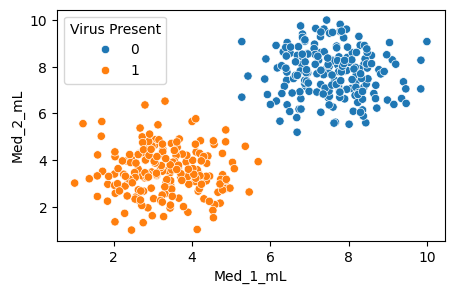

In [6]:
plt.figure(figsize=(5,3))
sns.scatterplot(x='Med_1_mL',y='Med_2_mL',hue='Virus Present',data=df)

# Support Vector Machine

In [7]:
from sklearn.svm import SVC

In [8]:
X = df.drop('Virus Present',axis=1)
y = df['Virus Present']

In [18]:
import sys
path = '/content/drive/MyDrive/Daksh_Gururkul_IITG_May_2025/22_SVMs/'

if path not in sys.path:
  sys.path.append(path)

In [19]:
from svm_margin_plot import plot_svm_boundary

In [23]:
model = SVC(kernel='linear',C=.005)
model.fit(X,y)

SVC(C=0.005, kernel='linear')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


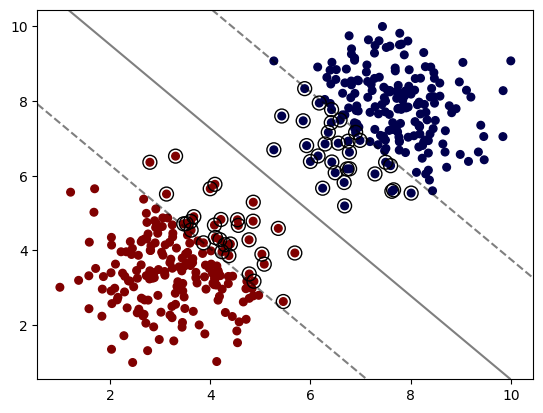

In [24]:
plot_svm_boundary(model,X,y)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


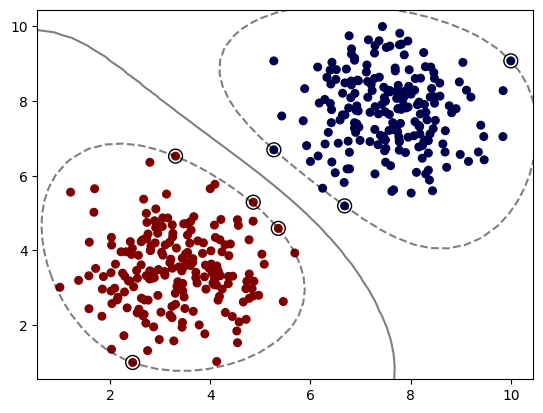

In [26]:
model = SVC(kernel='rbf',C=5)
model.fit(X,y)
plot_svm_boundary(model,X,y)

In [28]:
#help(SVC)

# Degree

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


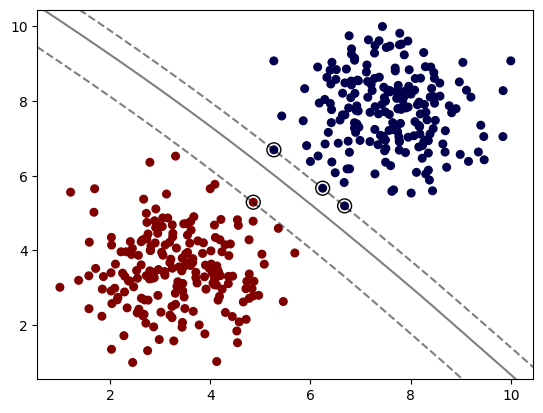

In [32]:
model = SVC(kernel='poly',C=1,degree=8)
model.fit(X,y)
plot_svm_boundary(model,X,y)

#Gamma in RBF

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


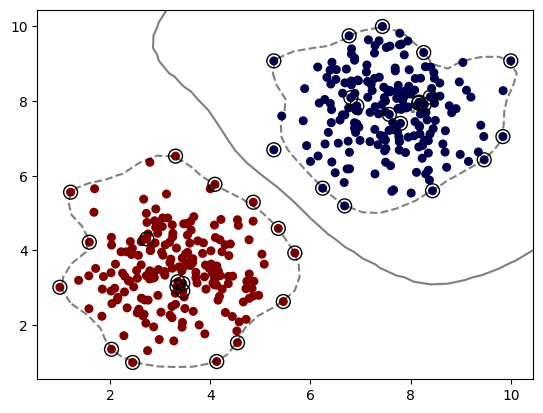

In [38]:
model = SVC(kernel='rbf',C=1,gamma='auto') #gamma : 'scale' or 'auto'
model.fit(X,y)
plot_svm_boundary(model,X,y)

# Grid Search

In [39]:
from sklearn.model_selection import GridSearchCV

In [40]:
svm = SVC()
param_grid = {'C':[0.01,0.1,0.5,1],
              'kernel':['linear','rbf']}

In [41]:
grid = GridSearchCV(svm,param_grid)

In [42]:
grid.fit(X,y)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 0.5, 1], 'kernel': ['linear', 'rbf']})

In [43]:
grid.best_score_

np.float64(1.0)

In [44]:
grid.best_params_

{'C': 0.01, 'kernel': 'linear'}